# Part II. Exploratory Data Analysis (EDA)

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
TARGET_COL = 'Attrition'
sns.set_style("whitegrid")
plt.rcParams.update({'figure.figsize': (10, 6), 'axes.titlesize': 13})

import os
os.makedirs("results", exist_ok=True)

In [ ]:
df_raw = pd.read_csv("../data/raw/WA_Fn-UseC_-HR-Employee-Attrition.csv")
df = df_raw.copy()

cols_to_drop = ['EmployeeCount', 'Over18', 'StandardHours', 'EmployeeNumber']
df = df.drop(columns=[c for c in cols_to_drop if c in df.columns])
df[TARGET_COL] = df[TARGET_COL].map({'Yes': 1, 'No': 0})
df = df.drop_duplicates(keep='first').reset_index(drop=True)

num_cols = df.select_dtypes(include=np.number).columns.drop(TARGET_COL).tolist()
cat_cols = df.select_dtypes(include=['object', 'string']).columns.tolist()
attrition_rate = df[TARGET_COL].mean() * 100

print(f"Dataset: {df.shape[0]:,} rows x {df.shape[1]} cols | Attrition rate: {attrition_rate:.2f}%")

## 2.2 Exploratory data analysis (EDA)

### 2.2.1 Univariate analysis: Numerical features

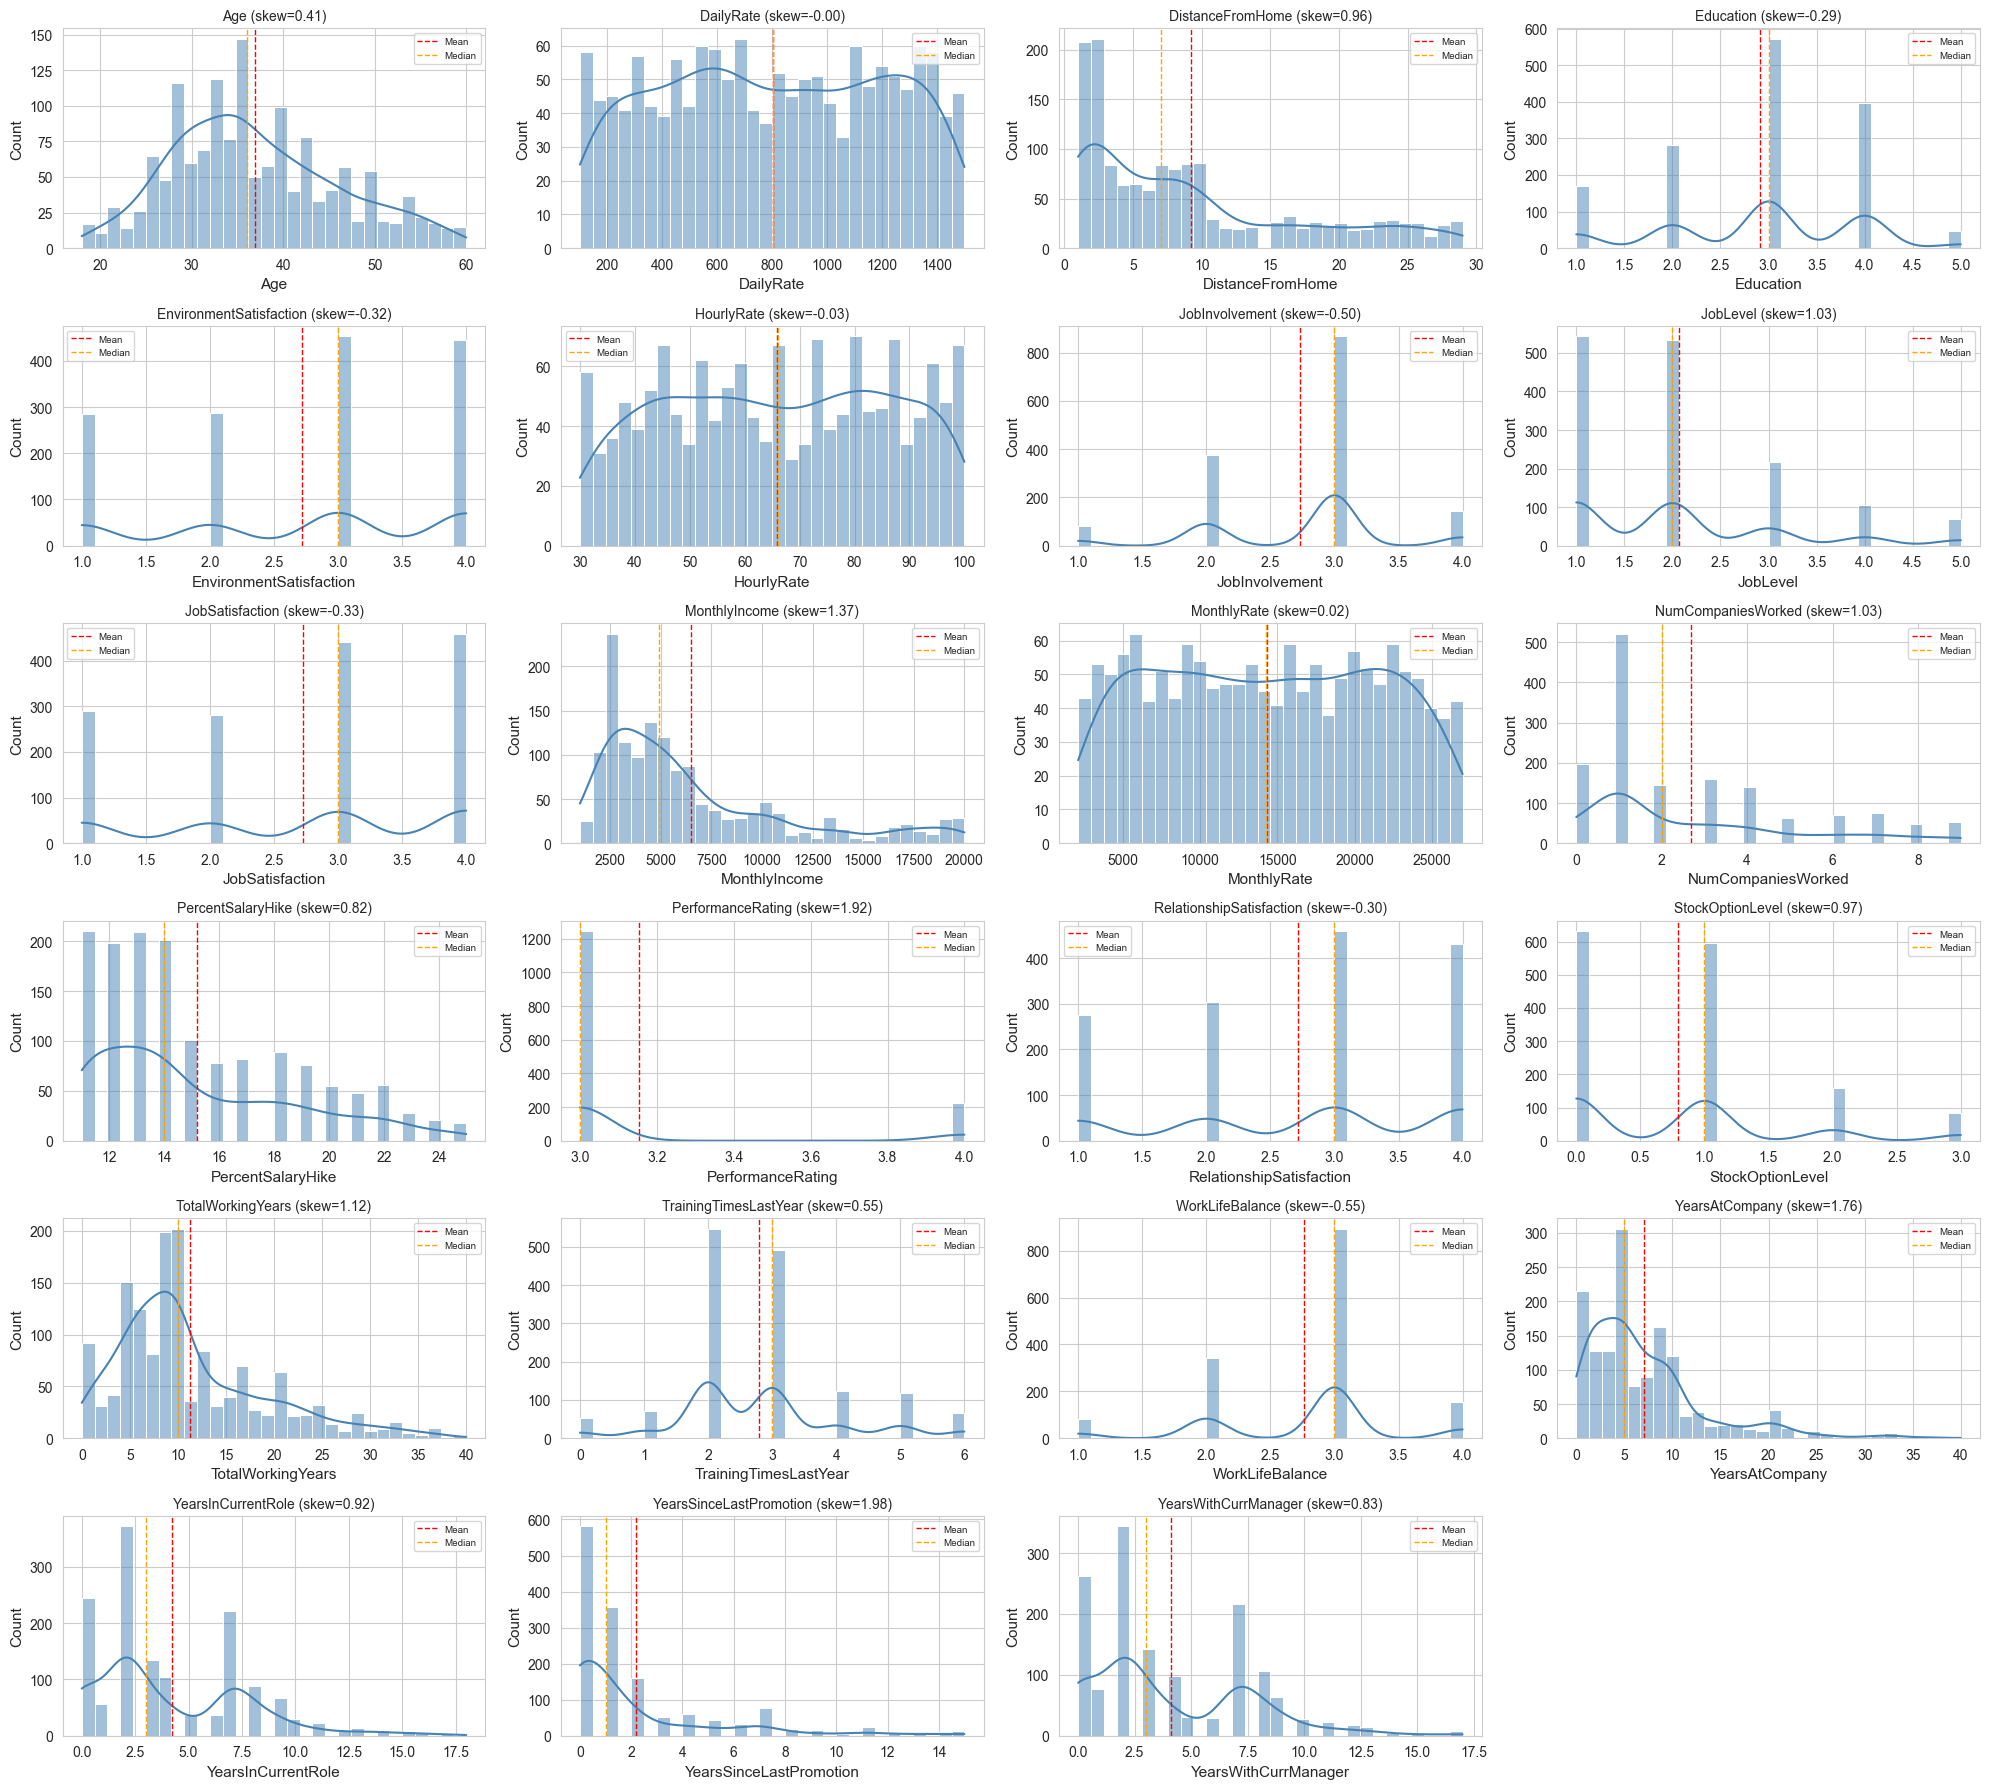

In [42]:
n_cols_grid = 4
n_rows_grid = (len(num_cols) + n_cols_grid - 1) // n_cols_grid

fig, axes = plt.subplots(n_rows_grid, n_cols_grid, figsize=(20, n_rows_grid * 3))
for ax, col in zip(axes.flat, num_cols):
    sns.histplot(df[col], kde=True, ax=ax, color='steelblue', bins=30)
    ax.axvline(df[col].mean(),   color='red',    ls='--', lw=1, label='Mean')
    ax.axvline(df[col].median(), color='orange', ls='--', lw=1, label='Median')
    ax.set_title(f"{col} (skew={df[col].skew():.2f})", fontsize=10)
    ax.legend(fontsize=7)
for ax in axes.flat[len(num_cols):]:
    ax.set_visible(False)
plt.tight_layout()
plt.savefig("results/eda_univariate.png", dpi=150, bbox_inches='tight')
plt.show()

### 2.2.2 Bivariate analysis: Numerical features vs Attrition

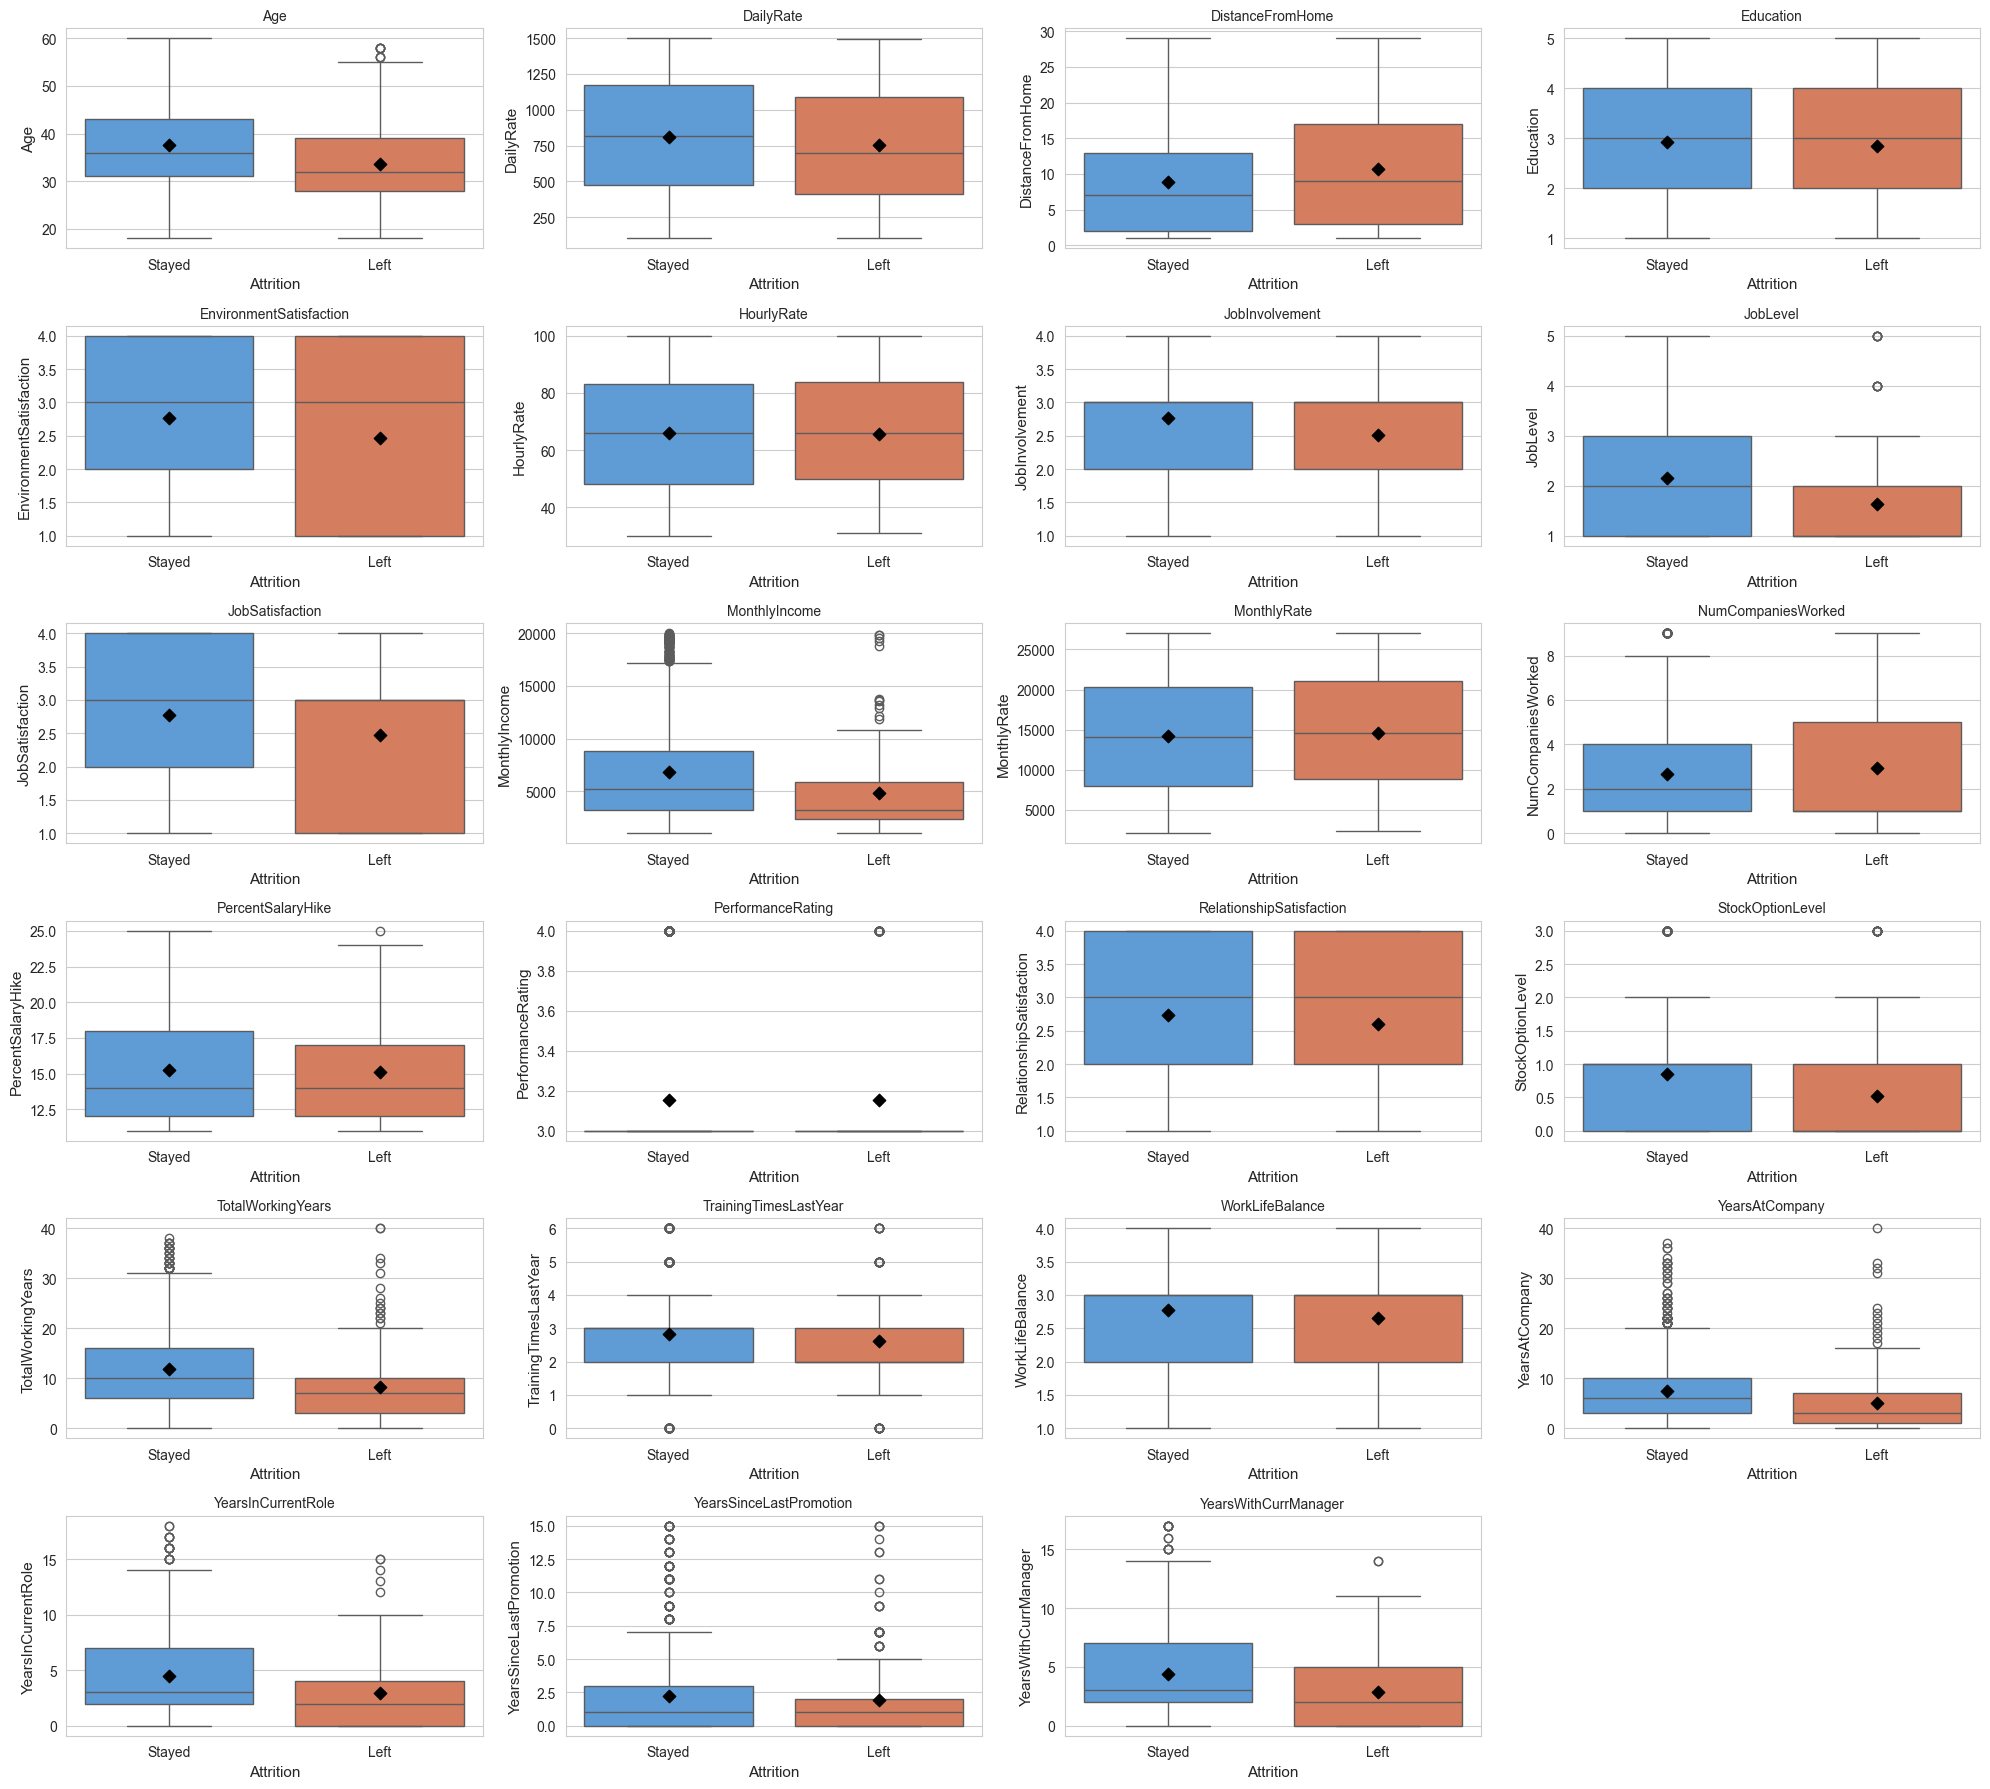

In [43]:
fig, axes = plt.subplots(n_rows_grid, n_cols_grid, figsize=(20, n_rows_grid * 3))
for ax, col in zip(axes.flat, num_cols):
    sns.boxplot(x=TARGET_COL, y=col, data=df, ax=ax,
                hue=TARGET_COL, palette=['#4C9BE8', '#E8754C'], legend=False)
    means = df.groupby(TARGET_COL)[col].mean()
    ax.scatter([0, 1], means, marker='D', s=40, color='black', zorder=3)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['Stayed', 'Left'])
    ax.set_title(col, fontsize=10)
for ax in axes.flat[len(num_cols):]:
    ax.set_visible(False)
plt.tight_layout()
plt.savefig("results/eda_bivariate_num.png", dpi=150, bbox_inches='tight')
plt.show()

### 2.2.3 Bivariate analysis: Categorical features vs Attrition

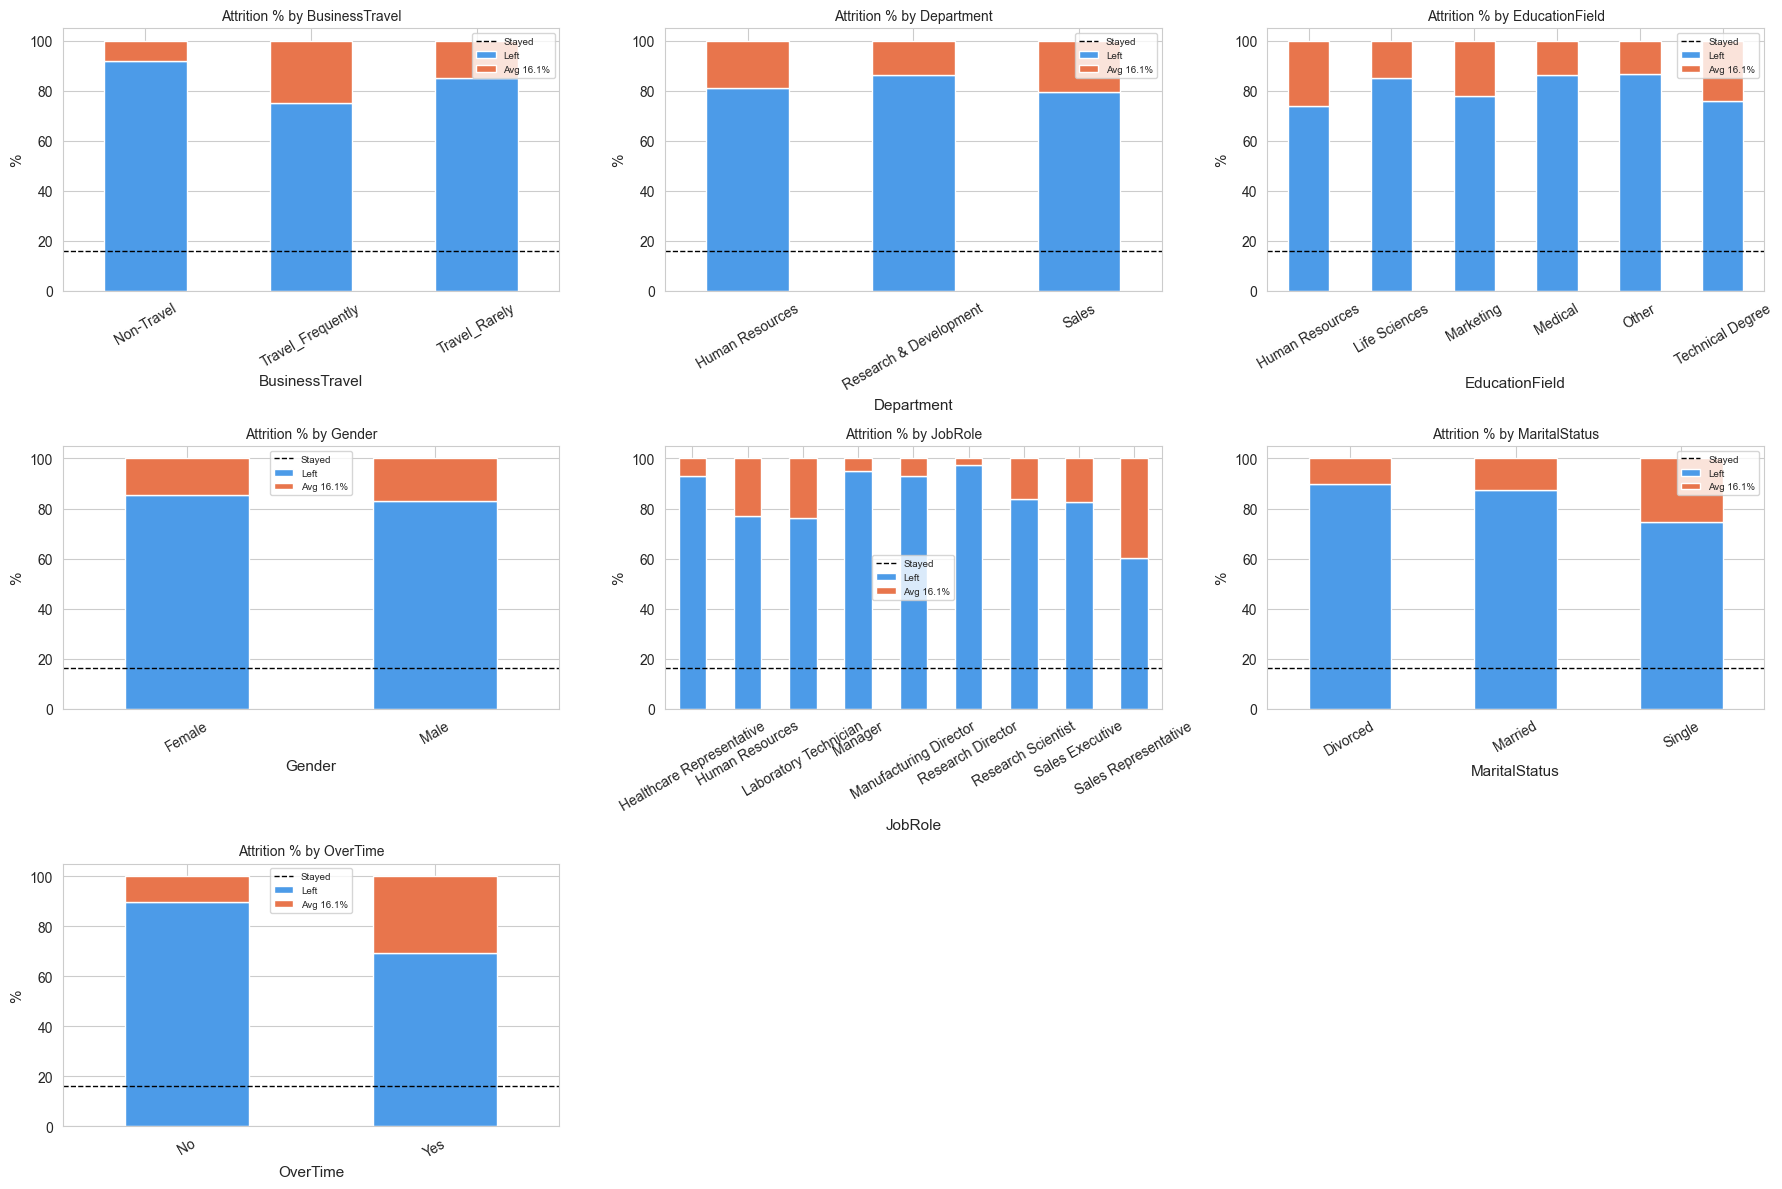

In [44]:
n_cat = len(cat_cols)
n_cat_cols = 3
n_cat_rows = (n_cat + n_cat_cols - 1) // n_cat_cols

fig, axes = plt.subplots(n_cat_rows, n_cat_cols, figsize=(18, n_cat_rows * 4))
for ax, col in zip(axes.flat, cat_cols):
    ct = pd.crosstab(df[col], df[TARGET_COL], normalize='index') * 100
    ct.plot(kind='bar', stacked=True, ax=ax,
            color=['#4C9BE8', '#E8754C'], rot=30, legend=False)
    ax.axhline(attrition_rate, color='black', ls='--', lw=1)
    ax.set_title(f"Attrition % by {col}", fontsize=10)
    ax.set_ylabel("%")
    ax.legend(['Stayed', 'Left', f'Avg {attrition_rate:.1f}%'], fontsize=7)
for ax in axes.flat[n_cat:]:
    ax.set_visible(False)
plt.tight_layout()
plt.savefig("results/eda_bivariate_cat.png", dpi=150, bbox_inches='tight')
plt.show()

### 2.2.4 Targeted group analysis

In [45]:
role_attrition = (
    df.groupby('JobRole')[TARGET_COL]
      .agg(['count', 'mean'])
      .rename(columns={'mean': 'attrition_rate'})
      .sort_values('attrition_rate', ascending=False)
)
role_attrition['attrition_rate'] = (role_attrition['attrition_rate']*100).round(2)
role_attrition

,count,attrition_rate
JobRole,,
Sales Representative,83,39.76
Laboratory Technician,259,23.94
Human Resources,52,23.08
Sales Executive,326,17.48
Research Scientist,292,16.10
Manufacturing Director,145,6.90
Healthcare Representative,131,6.87
Manager,102,4.90
Research Director,80,2.50


In [46]:
ot_attrition = df.groupby('OverTime')[TARGET_COL].mean() * 100
ot_multiplier = ot_attrition['Yes']/ot_attrition['No']

pd.DataFrame({
    'OverTime': ['No', 'Yes'],
    'attrition_rate': [round(ot_attrition['No'], 2), round(ot_attrition['Yes'], 2)],
    'multiplier': ['1.00x (baseline)', f'{ot_multiplier:.2f}x']
})

,OverTime,attrition_rate,multiplier
0,No,10.44,1.00x (baseline)
1,Yes,30.53,2.93x


### 2.2.5 Multivariate analysis: Correlation Matrix

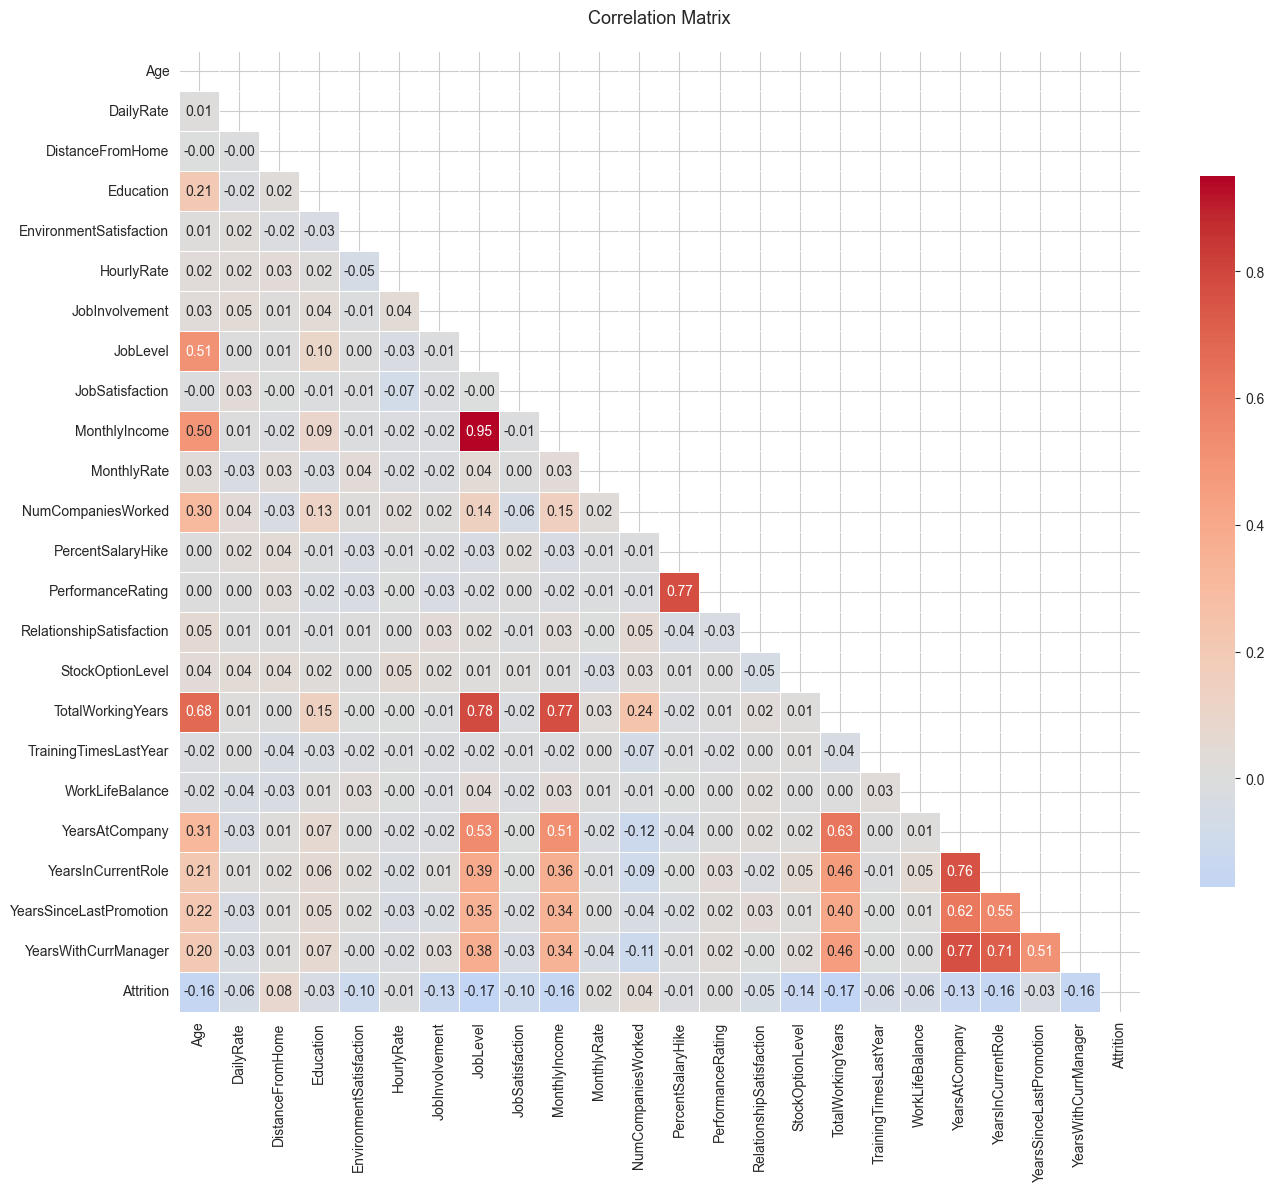

In [47]:
corr = df[num_cols + [TARGET_COL]].corr()
fig, ax = plt.subplots(figsize=(14, 12))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True, linewidths=0.5, cbar_kws={'shrink': 0.7}, ax=ax)
ax.set_title("Correlation Matrix", pad=20)
plt.tight_layout()
plt.savefig("results/correlation_matrix.png", dpi=150, bbox_inches='tight')
plt.show()

In [48]:
target_corr = corr[TARGET_COL].drop(TARGET_COL).abs().sort_values(ascending=False)
target_corr.head(10).round(4).to_frame('|correlation|')

,|correlation|
TotalWorkingYears,0.1711
JobLevel,0.1691
YearsInCurrentRole,0.1605
MonthlyIncome,0.1598
Age,0.1592
YearsWithCurrManager,0.1562
StockOptionLevel,0.1371
YearsAtCompany,0.1344
JobInvolvement,0.1300
JobSatisfaction,0.1035
